# UMEP 2026a Ground Scheme (experimental)

SOLWEIG's baseline ground model parameterises surface temperature with a sinusoidal
diurnal wave. UMEP's 2026a generation introduces an alternative, prognostic scheme:
a force-restore surface temperature driven by the Objective Hysteresis Model
(Grimmond et al. 1991), with a slab model for water, plus a solid-angle view-factor
model for the outgoing longwave radiation. This library ports that scheme behind two
opt-in flags:

- `use_ground_scheme=True` — force-restore/OHM ground surface temperature
- `use_outgoing_longwave=True` — solid-angle outgoing longwave (currently required together)

**Status: experimental, off by default.** The port matches the upstream reference
implementation component by component, but a field comparison against measured Tmrt at
three Gothenburg sites shows the scheme as currently published runs substantially warmer
than observations (see `VALIDATION.md`, section "UMEP 2026a ground scheme"). A question
about the radiation composition is open with the upstream developers. Use the flags to
explore the scheme's behaviour, not for production Tmrt.

Requirements: a land-cover grid (classes 0/1/2/5/6/7), and the raster must fit in a
single tile (tiled processing is not yet supported with the scheme).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import solweig

# Resolve the repo root so this notebook runs from the repo root or docs/tutorials/
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "demos").exists())

DATA_DIR = ROOT / "demos/data/Goteborg_SWEREF99_1200"
WORK_DIR = ROOT / "temp/tutorial_cache/gbg"
WORK_DIR.mkdir(parents=True, exist_ok=True)

assert (DATA_DIR / "DSM_KRbig.tif").exists(), f"Demo data not found at {DATA_DIR.resolve()}"

## 1. Prepare the surface

The Gothenburg demo area (central Gothenburg, 1 m resolution) ships with a land-cover
grid — paved, buildings, grass, and water — which the ground scheme requires. Each
class gets its own heat capacity, thermal diffusivity, and OHM coefficients from the
bundled materials parameters.


In [2]:
surface = solweig.SurfaceData.prepare(
    dsm=str(DATA_DIR / "DSM_KRbig.tif"),
    dem=str(DATA_DIR / "DEM_KRbig.tif"),
    cdsm=str(DATA_DIR / "CDSM_KRbig.tif"),
    land_cover=str(DATA_DIR / "landcover.tif"),
    working_dir=str(WORK_DIR / "working"),
)
print(f"Surface ready: {surface.dsm.shape}")
print(f"Land cover classes: {sorted(np.unique(surface.land_cover).tolist())}")

solweig.models.surface: Preparing surface data from GeoTIFF files...


solweig.io: No-data value is -3.4028234663852886e+38, replacing with NaN


solweig.models.surface_loading:   DSM: 234×223 pixels


solweig.models.surface_loading:   Extracted pixel size from DSM: 1.00 m


solweig.models.surface_loading:   CRS validated: SWEREF99 12 00 (EPSG:3007)


...

solweig.models.surface:   Crop: no trimming needed (valid bbox = full extent)


solweig.models.surface:   Cleaned rasters saved to /Users/dev/repos/solweig/temp/tutorial_cache/gbg/working/cleaned


solweig.models.surface: ✓ Surface data prepared successfully


Surface ready: (223, 234)


Land cover classes: [1, 2, 5, 7]


## 2. Weather: one summer day

The demo includes the classic Gothenburg 1997-06-06 met file used in the original
SOLWEIG publications.


In [3]:
weather_list = solweig.Weather.from_umep_met(DATA_DIR / "gbg19970606_2015a.txt", resample_hourly=False)
location = solweig.Location(latitude=57.7, longitude=12.0, utc_offset=1)

print(f"{len(weather_list)} timesteps: {weather_list[0].datetime} → {weather_list[-1].datetime}")

solweig.models.weather: Loaded 24 timesteps from UMEP met: 1997-06-06 00:00 → 1997-06-06 23:00


24 timesteps: 1997-06-06 00:00:00 → 1997-06-06 23:00:00


## 3. Run baseline and scheme

Two identical runs; only the two flags differ. The scheme initialises its ground and
deep-soil temperatures from the first day's air temperature series and carries the
force-restore state (temperature and heat fluxes) between timesteps.


In [4]:
summary_baseline = solweig.calculate(
    surface=surface,
    weather=weather_list,
    location=location,
    output_dir=str(WORK_DIR / "output_baseline"),
)

summary_scheme = solweig.calculate(
    surface=surface,
    weather=weather_list,
    location=location,
    output_dir=str(WORK_DIR / "output_scheme"),
    use_ground_scheme=True,
    use_outgoing_longwave=True,
)

solweig.tiling: Resource-aware tile sizing (context=solweig): GPU budget=30,150,672,384 bytes, RAM=5,901,565,952 available of 51,539,607,552 total, max_tile_side=2714 px


solweig.timeseries: ============================================================


solweig.timeseries: Starting SOLWEIG timeseries calculation


solweig.timeseries:   Grid size: 234x223 pixels


solweig.timeseries:   Timesteps: 24


...

SOLWEIG timeseries: 100%|██████████| 24/24 [00:05<00:00,  4.76it/s]

solweig.timeseries: ============================================================


solweig.timeseries: Calculation complete: 24 timesteps processed


solweig.timeseries:   Total time: 5.0s (4.76 steps/s)


solweig.timeseries: ============================================================


## 4. Compare the daytime mean Tmrt

The spatial pattern stays similar (shadows and sky view dominate), but the scheme
shifts the level upward — the warm bias documented in `VALIDATION.md`.


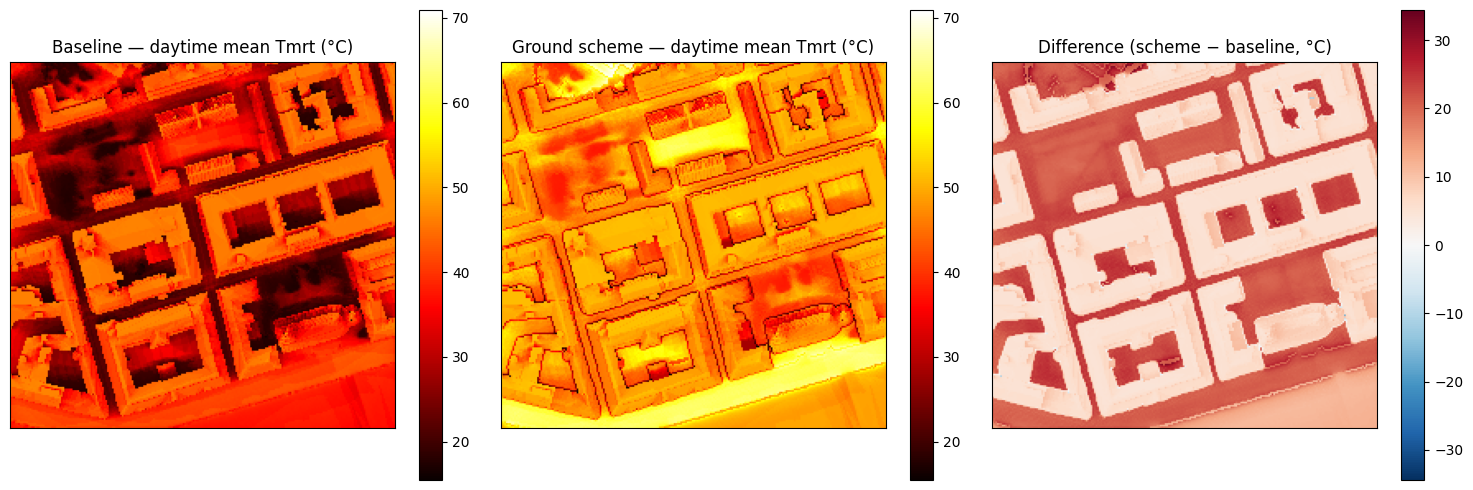

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(summary_baseline.tmrt_day_mean)
vmax = np.nanmax(summary_scheme.tmrt_day_mean)

im0 = axes[0].imshow(summary_baseline.tmrt_day_mean, cmap="hot", vmin=vmin, vmax=vmax)
axes[0].set_title("Baseline — daytime mean Tmrt (°C)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(summary_scheme.tmrt_day_mean, cmap="hot", vmin=vmin, vmax=vmax)
axes[1].set_title("Ground scheme — daytime mean Tmrt (°C)")
plt.colorbar(im1, ax=axes[1])

diff = summary_scheme.tmrt_day_mean - summary_baseline.tmrt_day_mean
im2 = axes[2].imshow(diff, cmap="RdBu_r", vmin=-np.nanmax(np.abs(diff)), vmax=np.nanmax(np.abs(diff)))
axes[2].set_title("Difference (scheme − baseline, °C)")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Diurnal comparison


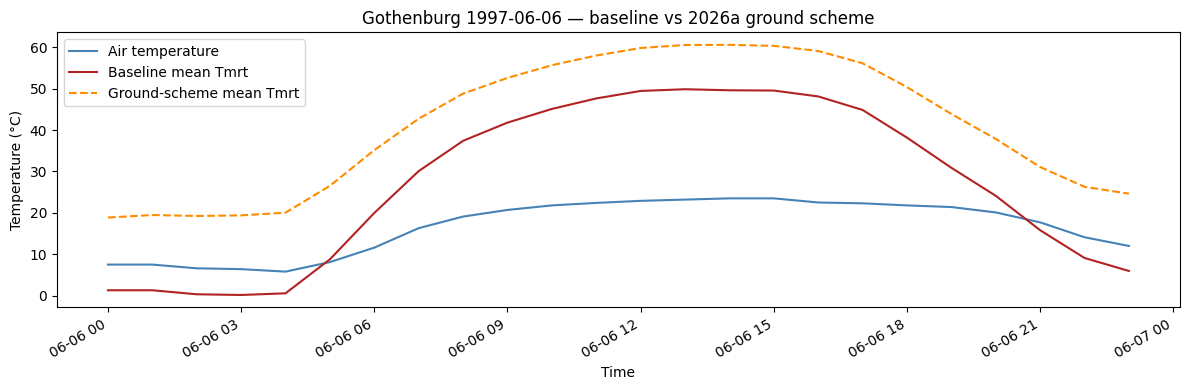

In [6]:
ts_b = summary_baseline.timeseries
ts_s = summary_scheme.timeseries

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts_b.datetime, ts_b.ta, label="Air temperature", color="steelblue")
ax.plot(ts_b.datetime, ts_b.tmrt_mean, label="Baseline mean Tmrt", color="firebrick")
ax.plot(ts_s.datetime, ts_s.tmrt_mean, label="Ground-scheme mean Tmrt", color="darkorange", linestyle="--")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Time")
ax.legend()
ax.set_title("Gothenburg 1997-06-06 — baseline vs 2026a ground scheme")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Interpretation and caveats

- The scheme changes the ground physics only: shadows, sky view factors, and shortwave
  are shared with the baseline, so the spatial structure is unchanged.
- The prognostic ground temperature removes the baseline's morning warm-up artefact and
  gives water bodies realistic thermal inertia (they warm slowly, stay warm after sunset).
- Against field measurements, however, the scheme currently overestimates Tmrt by
  roughly 12–21 °C (anisotropic sky) because of how the directional side longwave is
  composed into the radiation budget. Until that is resolved upstream, treat scheme
  output as qualitative.
- Details: `VALIDATION.md` (field comparison), the ground temperature spec
  (physics), and the settings guide (flag rules).
